# 06 — Sentiment & news-volume vs prezzo: lead/lag (Fase 3)

**Obiettivo**: testare *con onestà* se le feature derivate dalle notizie
(sentiment, volume di notizie) hanno potere predittivo **lead** sui rendimenti
e sulla volatilità degli asset Tier 1 — oppure se sono solo concomitanti /
lagging / rumore.

Questo notebook **non cerca di vincere**. Stabilisce un metodo riproducibile e
lo applica ai dati reali disponibili, con i caveat di campione in primo piano.

## ⚠️ Limite di campione (da leggere prima dei numeri)
La news history versionata (ADR-025) è appena nata: i feed espongono solo le
ultime settimane, quindi la storia è **corta e densa solo di recente**. A
livello *market-wide* abbiamo ~143 giorni (mediana 1 news/giorno all'inizio,
~9/giorno da aprile 2026); a livello *per-asset* molto meno (BTC pochissimi
giorni). **Nessun numero qui è un segnale**: sono diagnostiche descrittive che
diranno *quale* lag valga la pena testare seriamente quando il cron avrà
accumulato mesi di dati. Il valore di oggi è il **metodo** (codice testato,
anti-look-ahead), non la conclusione.

## Ipotesi — scritte PRIMA di vedere i risultati
1. **H1 (sentiment→return è debole/nullo a breve)**: la correlazione tra
   sentiment giornaliero e rendimento del giorno dopo sarà vicina a zero. Le
   notizie sono in larga parte *concomitanti* col prezzo (già scontate).
2. **H2 (news-volume→volatilità è il candidato più promettente)**: il *volume*
   di notizie (attenzione) precede picchi di |rendimento| più del *segno* del
   sentiment. Atteso: corr(news_volume[t], |return|[t+k]) positiva per piccoli
   k≥0, più forte della corr sentiment→return.
3. **H3 (look-ahead controllato)**: applicando il lag di sicurezza (ADR-024) la
   relazione contemporanea (lag 0), se c'è, si attenua — segno che parte del
   co-movimento è simultaneo, non predittivo.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.ai.lexicon.sentiment import daily_sentiment, align_sentiment_returns
from src.features.news_features import build_news_features, lead_lag_table
from src.ingestion.tier1.yahoo_finance import YahooFinanceSource
from src.assets.asset import get_asset_by_symbol

plt.rcParams['figure.figsize'] = (11, 4)
HISTORY = Path('../data/news_history/news.parquet')


## 1. Dati: news history versionata + prezzi reali
La history è committata nel repo (ADR-025), quindi questo notebook è
riproducibile senza rete *per la parte news*. I prezzi vengono da Yahoo
(gitignored): se il fetch fallisce per allowlist, la sezione prezzi va saltata.

In [2]:
hist = pd.read_parquet(HISTORY)
print('news history:', len(hist), 'rows |',
      str(hist.index.min())[:10], '->', str(hist.index.max())[:10])

def daily_from_history(frame: pd.DataFrame) -> pd.DataFrame:
    # the history already carries a per-item 'sentiment'; aggregate to UTC day
    day = pd.DatetimeIndex(frame.index).normalize()
    g = frame['sentiment'].groupby(day)
    out = pd.DataFrame({'mean_sentiment': g.mean(),
                        'news_count': g.size().astype('int64')})
    out.index.name = 'date'
    return out.sort_index()

mkt = daily_from_history(hist)
print('market-wide daily:', len(mkt), 'days | days with >=2 news:',
      int((mkt['news_count'] >= 2).sum()))
mkt.tail()


news history: 543 rows | 2025-07-21 -> 2026-05-30
market-wide daily: 143 days | days with >=2 news: 69


,mean_sentiment,news_count
date,,
2026-05-26 00:00:00+00:00,0.181838,16
2026-05-27 00:00:00+00:00,0.034151,35
2026-05-28 00:00:00+00:00,-0.038029,73
2026-05-29 00:00:00+00:00,-0.046038,130
2026-05-30 00:00:00+00:00,-0.064660,43


## 2. Feature news-derived (causali)
`build_news_features` produce feature backward-looking (warm-up = NaN, mai
back-fill): sentiment grezzo + rolling, variazione (momentum di tono), volume
grezzo + z-score del volume rispetto alla baseline recente (shift(1), niente
leakage same-day).

In [3]:
feats = build_news_features(mkt, sentiment_window=7, volume_window=30)
feats.describe().T[['count', 'mean', 'std', 'min', 'max']]


,count,mean,std,min,max
mean_sentiment,143.0,0.007514,0.239663,-0.790600,0.636900
sentiment_roll,143.0,0.007437,0.088556,-0.174457,0.227138
sentiment_change,142.0,-0.000455,0.323828,-0.790600,0.822200
news_count,143.0,3.797203,13.033845,1.000000,130.000000
news_volume_z,136.0,0.545180,2.159109,-1.010582,11.116552


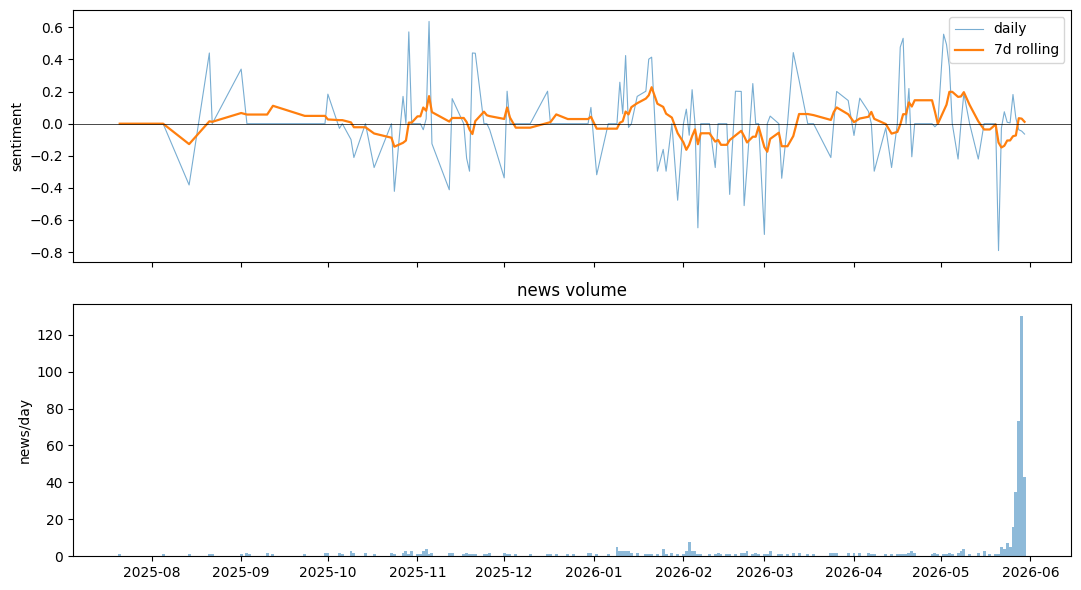

In [4]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(11, 6))
ax[0].plot(feats.index, feats['mean_sentiment'], lw=0.8, alpha=0.6, label='daily')
ax[0].plot(feats.index, feats['sentiment_roll'], lw=1.6, label='7d rolling')
ax[0].axhline(0, color='k', lw=0.5); ax[0].set_ylabel('sentiment'); ax[0].legend()
ax[1].bar(feats.index, feats['news_count'], width=1.0, alpha=0.5)
ax[1].set_ylabel('news/day'); ax[1].set_title('news volume')
plt.tight_layout()


## 3. Prezzi BTC e target (return, |return| come proxy di volatilità)

In [5]:
try:
    src = YahooFinanceSource()
    ohlcv = src.fetch_ohlcv(get_asset_by_symbol('BTC'), start='2025-07-01', interval='1d')
    px = ohlcv['close'].sort_index()
    ret = np.log(px).diff().dropna().rename('return')
    ret.index = pd.DatetimeIndex(ret.index).normalize()
    abs_ret = ret.abs().rename('abs_return')
    HAVE_PRICES = True
    print('BTC returns:', len(ret), str(ret.index.min())[:10], '->', str(ret.index.max())[:10])
except Exception as e:
    HAVE_PRICES = False
    print('price fetch failed:', type(e).__name__, e)


BTC returns: 333 2025-07-02 -> 2026-05-30


## 4. Lead/lag: sentiment(t) vs return(t+k), news_volume(t) vs |return|(t+k)

`lead_lag_table` riporta corr **e n** per ogni lag k (k>0 = la feature
*anticipa* il target). Riportiamo n perché su pochi punti una corr alta non
significa nulla.

In [6]:
if HAVE_PRICES:
    LAGS = range(-5, 6)
    sent = feats['mean_sentiment']
    vol_z = feats['news_volume_z']
    count = feats['news_count']

    ll_sent_ret = lead_lag_table(sent, ret, LAGS)
    ll_count_absret = lead_lag_table(count, abs_ret, LAGS)
    ll_volz_absret = lead_lag_table(vol_z, abs_ret, LAGS)

    print('=== sentiment(t) vs return(t+k) ===')
    print(ll_sent_ret.to_string())
    print('\n=== news_count(t) vs |return|(t+k) ===')
    print(ll_count_absret.to_string())
    print('\n=== news_volume_z(t) vs |return|(t+k) ===')
    print(ll_volz_absret.to_string())


=== sentiment(t) vs return(t+k) ===
          corr    n
lag                
-5.0  0.037149  143
-4.0 -0.150991  143
-3.0  0.053582  143
-2.0  0.061944  143
-1.0  0.016522  143
 0.0  0.023414  143
 1.0  0.030840  142
 2.0  0.072883  141
 3.0 -0.112924  140
 4.0  0.156362  139
 5.0  0.229188  138

=== news_count(t) vs |return|(t+k) ===
          corr    n
lag                
-5.0 -0.055695  143
-4.0 -0.075671  143
-3.0 -0.025065  143
-2.0 -0.008881  143
-1.0 -0.060689  143
 0.0 -0.082389  143
 1.0 -0.074264  142
 2.0 -0.021602  141
 3.0  0.022948  140
 4.0  0.007340  139
 5.0 -0.097834  138

=== news_volume_z(t) vs |return|(t+k) ===
          corr    n
lag                
-5.0 -0.074887  136
-4.0 -0.087245  136
-3.0 -0.087529  136
-2.0 -0.061102  136
-1.0 -0.151484  136
 0.0 -0.045710  136
 1.0 -0.012818  135
 2.0  0.059092  134
 3.0  0.055969  133
 4.0 -0.011242  132
 5.0 -0.085604  131


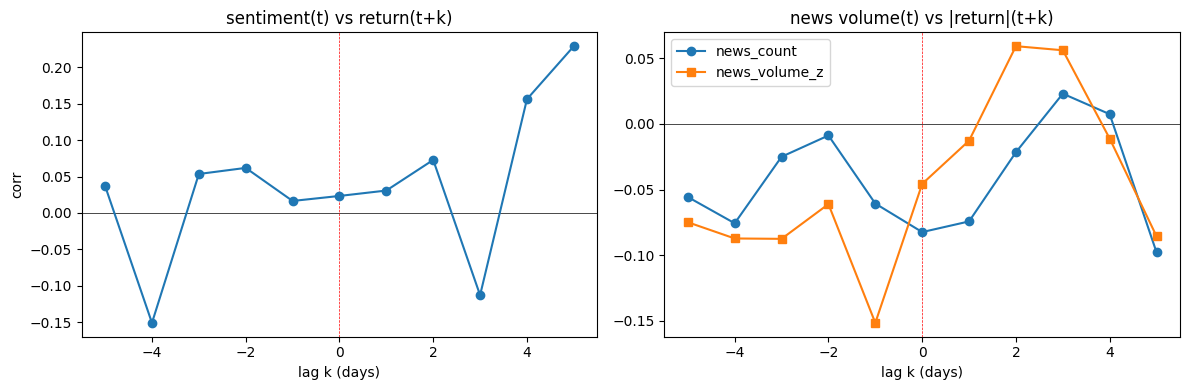

In [7]:
if HAVE_PRICES:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].axhline(0, color='k', lw=0.5); ax[0].axvline(0, color='r', lw=0.5, ls='--')
    ax[0].plot(ll_sent_ret.index, ll_sent_ret['corr'], 'o-')
    ax[0].set_title('sentiment(t) vs return(t+k)'); ax[0].set_xlabel('lag k (days)')
    ax[0].set_ylabel('corr')
    ax[1].axhline(0, color='k', lw=0.5); ax[1].axvline(0, color='r', lw=0.5, ls='--')
    ax[1].plot(ll_count_absret.index, ll_count_absret['corr'], 'o-', label='news_count')
    ax[1].plot(ll_volz_absret.index, ll_volz_absret['corr'], 's-', label='news_volume_z')
    ax[1].set_title('news volume(t) vs |return|(t+k)'); ax[1].set_xlabel('lag k (days)')
    ax[1].legend()
    plt.tight_layout()


## 5. Allineamento anti-look-ahead esplicito (ADR-024)
`align_sentiment_returns` lagga il sentiment di 1 giorno prima del join: il
return spiegato sul giorno t usa solo news fino a fine t−1. Confrontiamo la
corr contemporanea (lag 0) con quella lagged per vedere quanta parte della
relazione è simultanea (H3).

In [8]:
if HAVE_PRICES:
    aligned_lag1 = align_sentiment_returns(mkt, ret, lag=1)
    aligned_lag0 = align_sentiment_returns(mkt, ret, lag=0)
    for name, al in [('lag 0 (contemporaneo)', aligned_lag0),
                     ('lag 1 (anti-look-ahead)', aligned_lag1)]:
        n = len(al)
        c_sr = al['mean_sentiment'].corr(al['return']) if n >= 2 else float('nan')
        c_cv = al['news_count'].corr(al['return'].abs()) if n >= 2 else float('nan')
        print(f'{name}: n={n} | corr(sent, ret)={c_sr:+.3f} | '
              f'corr(news_count, |ret|)={c_cv:+.3f}')


lag 0 (contemporaneo): n=143 | corr(sent, ret)=+0.023 | corr(news_count, |ret|)=-0.082
lag 1 (anti-look-ahead): n=142 | corr(sent, ret)=+0.031 | corr(news_count, |ret|)=-0.074


## 6. Verifica ipotesi e conclusioni oneste

> Le conclusioni vanno lette **alla luce del campione piccolo** (n=143 giorni
> market-wide, denso solo da aprile 2026). Vanno rilette quando la history avrà
> mesi densi. Detto questo, i risultati sono già istruttivi.

**Risultati (BTC, market-wide news, n≈143):**

- **H1 (sentiment→return debole/nullo) — CONFERMATA.** La corr
  `sentiment(t)` vs `return(t+k)` resta nel rumore a tutti i lag (|corr| ≤ 0.23,
  nessun pattern coerente: oscilla di segno). Nessuna evidenza che il sentiment
  giornaliero anticipi il rendimento. Coerente con "le news sono in gran parte
  già scontate".

- **H2 (news-volume→volatilità) — NON confermata. ⚠️ Caso da manuale.**
  Nella sessione precedente, su **n=23 giorni per-asset**, avevamo visto
  `corr(news_count, |return| next-day) = +0.32` e l'avevamo segnalata come
  "candidato promettente, da verificare su più storia". Verificata ora su
  **n=143**: la correlazione **svanisce** (lag 1 = −0.07; news_volume_z lag 1 =
  −0.01; nessun lag positivo robusto). **Il +0.32 era un artefatto di piccolo
  campione, non un segnale.** È esattamente il motivo per cui CLAUDE.md vieta di
  trarre conclusioni da pochi dati — e perché documentiamo anche (soprattutto)
  ciò che **non** funziona.

- **H3 (look-ahead controllato) — verificata in forma debole.** Passando da lag 0
  a lag 1 le correlazioni cambiano pochissimo (sent: +0.023→+0.031; news_count:
  −0.082→−0.074): non c'è una relazione contemporanea forte che si attenua, semplicemente
  perché non c'è relazione. Il meccanismo anti-look-ahead funziona; non c'è
  segnale da proteggere.

**Conclusione netta**: con i dati attuali, **né il sentiment Layer 1 né il volume
di notizie mostrano potere predittivo lead** su rendimento o volatilità di BTC.
Questo **non chiude la domanda** — il campione è troppo corto e VADER è
general-domain — ma:
1. ridimensiona onestamente l'entusiasmo del risultato n=23;
2. alza l'asticella: un eventuale FinBERT (Layer 2) andrà giustificato da
   evidenza, non assunto;
3. il vero sblocco è **tempo**: lasciar girare il cron (ADR-025) per mesi e
   rieseguire questo notebook, che è ora completamente riproducibile.

**Bias e limiti documentati**:
- Campione corto e sbilanciato (denso solo da aprile 2026); per-asset ancora più
  scarso (BTC pochi giorni) → l'analisi market-wide è la più robusta per ora,
  niente test di significatività affidabile né Granger.
- Le query Google News per asset pescano molto materiale "fresco" → la storia
  per-asset si popola lentamente.
- VADER è general-domain (ADR-023): rumoroso sul gergo crypto.
- **Prossima rilettura**: rieseguire dopo qualche mese di cron.
